# Free Body Diagrams → Differential Equations → Time-Domain
## Rigorous Derivation: Every Force, Every Sign, Every Mission

**Method every time:**  
1. Draw the FBD — isolate the body, label every force with direction  
2. Write $\sum F = ma$ strictly from the diagram  
3. SymPy: rearrange to standard ODE form, solve analytically  
4. NumPy: integrate numerically and verify  
5. Torch batch: sweep over parameters  

**Missions:** Block on surface · Atwood machine · Spring-mass-damper · Inclined plane · Double pendulum · Rocket thrust

In [1]:
import sympy as sp
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.transforms as transforms
from scipy.integrate import solve_ivp
from IPython.display import display, Math

sp.init_printing(use_latex='mathjax')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 110})
print('ready')

ready


---
# How to Read a Free Body Diagram — Zero-Mission

**Strict rules (the "diff nazi" conventions):**
1. Isolate ONE body. Remove all contacts and replace with force vectors.
2. Choose a positive direction and STICK to it.
3. Every force gets a sign. Normal forces are always perpendicular. Friction opposes motion.
4. $\sum F_x = ma_x$, $\sum F_y = ma_y$, separately — never mix axes.
5. The ODE is the **exact** $\sum F = ma$ with nothing cancelled prematurely.

In [2]:
m, g, t = sp.symbols('m g t', positive=True)
x = sp.Function('x')

force_types = [
    ('Weight',           r'W = mg',                        'always downward (-y)'),
    ('Normal force',     r'N \perp \text{surface}',        'into surface = reaction'),
    ('Friction',         r'f = \mu_k N',                   'opposes velocity direction'),
    ('Spring',           r'F_s = -kx',                     'restoring, toward equilibrium'),
    ('Damper',           r'F_d = -c\dot{x}',               'opposes velocity'),
    ('Tension',          r'T',                              'along rope, away from body'),
    ('Applied force',    r'F_A',                            'given direction'),
    ('Buoyancy',         r'F_b = \rho g V',                'upward (+y)'),
    ('Drag',             r'F_{\text{drag}} = -\frac{1}{2}C_D \rho A v^2 \text{sgn}(v)', 'opposes velocity'),
]

print('Force type reference:\n')
for name, formula, rule in force_types:          # loop over force types
    display(Math(rf'\text{{{name}}}: \quad {formula} \quad\Rightarrow\quad \text{{{rule}}}'))

Force type reference:



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

---
# Mission 1 — Block on Horizontal Surface with Friction

```
        F_A →
   ┌─────────┐
   │    m    │  ← FBD: W↓  N↑  F_A→  f←
   └─────────┘
  ///friction///// 
```

**FBD forces (positive x = right, positive y = up):**  
- x: $F_A - f = ma$ where $f = \mu_k N$  
- y: $N - mg = 0$ (no vertical acceleration)  
→ $N = mg$ → $f = \mu_k mg$  
→ $m\ddot{x} = F_A - \mu_k mg$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

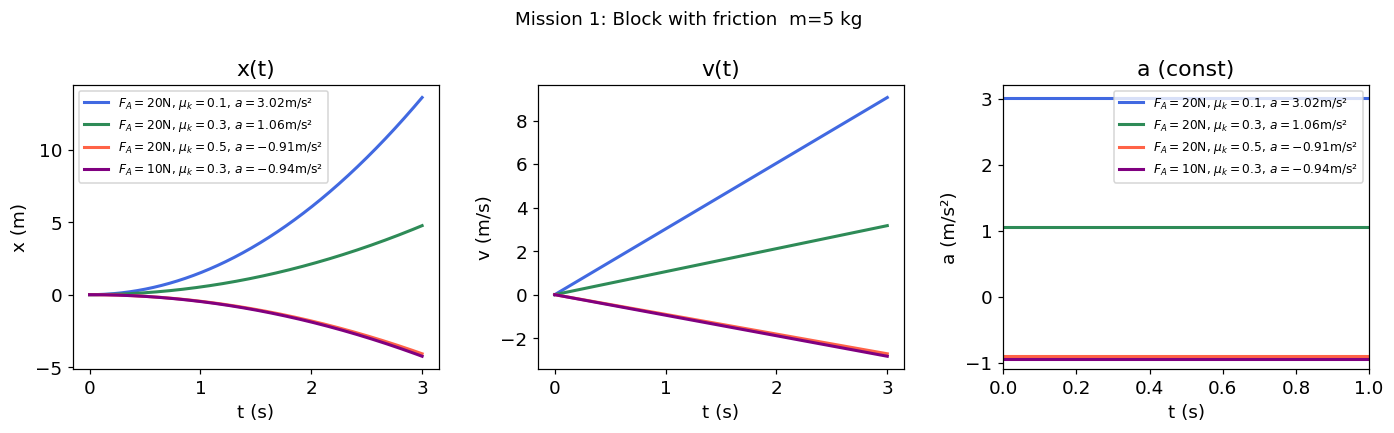

In [3]:
m1, mu_k, FA, g_s = sp.symbols('m mu_k F_A g', positive=True)
t_s = sp.Symbol('t', positive=True)
x1  = sp.Function('x')(t_s)

# ── strict FBD → ODE ──────────────────────────────────────────────────
N1   = m1 * g_s                           # from y equation
f1   = mu_k * N1                          # kinetic friction
EOM1 = sp.Eq(m1 * x1.diff(t_s,2), FA - f1)
display(Math(rf'\text{{FBD}} \Rightarrow \sum F_x = ma_x: \quad {sp.latex(EOM1)}'))

# solve for x(t) with x(0)=0, ẋ(0)=v0
v0_s = sp.Symbol('v_0', real=True)
a_net = (FA - f1)/m1
display(Math(rf'a = {sp.latex(a_net)} = \text{{constant}} \implies x(t) = v_0 t + \frac{{1}}{{2}}at^2'))

# ── NumPy: loop over (F_A, μ_k) pairs ─────────────────────────────────
t_arr = np.linspace(0, 3, 500)
m_v = 5.0; g_v = 9.81
combos = [
    (20, 0.1, 'royalblue'),
    (20, 0.3, 'seagreen'),
    (20, 0.5, 'tomato'),
    (10, 0.3, 'purple'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for FA_v, mu_v, col in combos:               # loop over parameter sets
    a_v = (FA_v - mu_v*m_v*g_v) / m_v
    x_v = 0.5 * a_v * t_arr**2
    v_v = a_v * t_arr
    label = rf'$F_A={FA_v}$N, $\mu_k={mu_v}$, $a={a_v:.2f}$m/s²'
    axes[0].plot(t_arr, x_v, color=col, lw=2, label=label)
    axes[1].plot(t_arr, v_v, color=col, lw=2)
    axes[2].axhline(a_v, color=col, lw=2, label=label)

axes[0].set_title('x(t)'); axes[0].set_xlabel('t (s)'); axes[0].set_ylabel('x (m)'); axes[0].legend(fontsize=8)
axes[1].set_title('v(t)'); axes[1].set_xlabel('t (s)'); axes[1].set_ylabel('v (m/s)')
axes[2].set_title('a (const)'); axes[2].set_xlabel('t (s)'); axes[2].set_ylabel('a (m/s²)'); axes[2].legend(fontsize=8)
plt.suptitle('Mission 1: Block with friction  m=5 kg', fontsize=12)
plt.tight_layout(); plt.show()

---
# Mission 2 — Atwood Machine

```
        ┌──pulley──┐
        │          │
     T↑ │        T↑│
    ┌───┐        ┌───┐
    │ m₁│        │ m₂│
    │   │        │   │
    └───┘        └───┘
    W₁↓            W₂↓
```

**FBD for each mass (positive = downward for each body):**  
- Mass 1: $m_1 g - T = m_1 a$  
- Mass 2: $T - m_2 g = m_2 a$  

Add: $(m_1 - m_2)g = (m_1+m_2)a$ → $a = \frac{m_1-m_2}{m_1+m_2}g$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

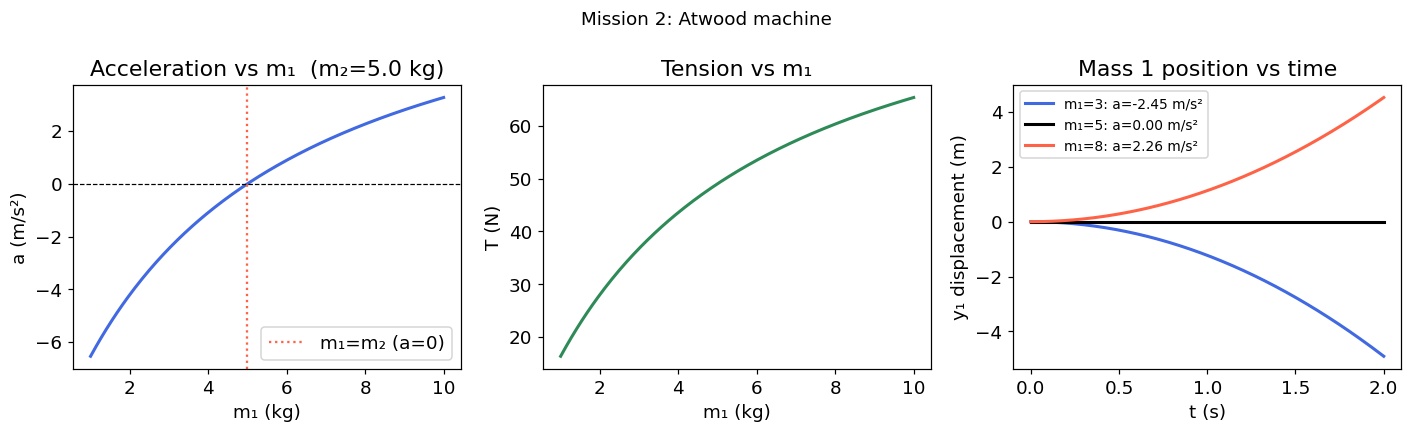

In [4]:
m1_s, m2_s, T_s, a_s2 = sp.symbols('m_1 m_2 T a', positive=True)

# ── strict FBD system ──────────────────────────────────────────────────
eq_m1 = sp.Eq(m1_s*g_s - T_s, m1_s*a_s2)
eq_m2 = sp.Eq(T_s - m2_s*g_s, m2_s*a_s2)
display(Math(rf'\text{{Mass 1}}: {sp.latex(eq_m1)}'))
display(Math(rf'\text{{Mass 2}}: {sp.latex(eq_m2)}'))

sol = sp.solve([eq_m1, eq_m2], [a_s2, T_s])
a_atwood = sol[a_s2]
T_atwood = sol[T_s]
display(Math(rf'a = {sp.latex(sp.simplify(a_atwood))}'))
display(Math(rf'T = {sp.latex(sp.simplify(T_atwood))}'))

# ── NumPy: loop over mass ratios ──────────────────────────────────────
m1_vals = np.linspace(1, 10, 200)
m2_fix  = 5.0
a_arr   = (m1_vals - m2_fix) / (m1_vals + m2_fix) * g_v
T_arr   = 2 * m1_vals * m2_fix / (m1_vals + m2_fix) * g_v

t_arr2 = np.linspace(0, 2, 300)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].plot(m1_vals, a_arr, color='royalblue', lw=2)
axes[0].axhline(0, color='k', lw=0.8, ls='--')
axes[0].set_xlabel('m₁ (kg)'); axes[0].set_ylabel('a (m/s²)')
axes[0].set_title(f'Acceleration vs m₁  (m₂={m2_fix} kg)')
axes[0].axvline(m2_fix, color='tomato', ls=':', label='m₁=m₂ (a=0)')
axes[0].legend()

axes[1].plot(m1_vals, T_arr, color='seagreen', lw=2)
axes[1].set_xlabel('m₁ (kg)'); axes[1].set_ylabel('T (N)')
axes[1].set_title('Tension vs m₁')

# time trajectories for 3 mass combos
for (m1v, m2v, col) in [(3,5,'royalblue'),(5,5,'k'),(8,5,'tomato')]:
    av = (m1v-m2v)/(m1v+m2v)*g_v
    axes[2].plot(t_arr2, 0.5*av*t_arr2**2, color=col, lw=2,
                 label=f'm₁={m1v}: a={av:.2f} m/s²')
axes[2].set_xlabel('t (s)'); axes[2].set_ylabel('y₁ displacement (m)')
axes[2].set_title('Mass 1 position vs time')
axes[2].legend(fontsize=9)

plt.suptitle('Mission 2: Atwood machine', fontsize=12)
plt.tight_layout(); plt.show()

---
# Mission 3 — Spring-Mass-Damper  (2nd-order ODE)

```
  wall ──k──┬──c──[ m ]──→ F(t)
            │
            x=0 (equilibrium)
```

**FBD (positive x = right):**  
- Spring: $F_s = -kx$ (restoring)  
- Damper: $F_d = -c\dot{x}$ (opposes velocity)  
- Applied: $F(t)$  

$m\ddot{x} + c\dot{x} + kx = F(t)$  

Natural frequency $\omega_n = \sqrt{k/m}$, damping ratio $\zeta = c/(2m\omega_n)$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

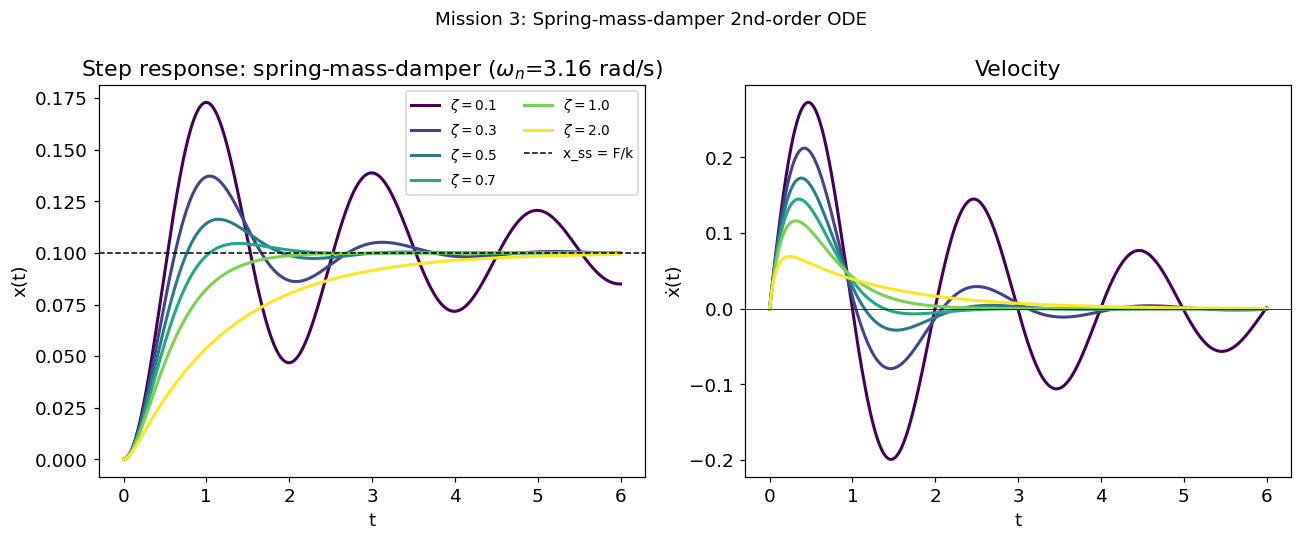

In [5]:
k_s, c_s, omega_n_s, zeta_s, s_lap = sp.symbols('k c omega_n zeta s', positive=True)
F_s = sp.Symbol('F', real=True)
t_sym = sp.Symbol('t', positive=True)
x_fn  = sp.Function('x')(t_sym)

# ── strict ODE from FBD ───────────────────────────────────────────────
EOM3 = sp.Eq(m*x_fn.diff(t_sym,2) + c_s*x_fn.diff(t_sym) + k_s*x_fn, F_s)
display(Math(rf'\text{{FBD}} \Rightarrow {sp.latex(EOM3)}'))

# standard form
EOM3_std = sp.Eq(x_fn.diff(t_sym,2) + 2*zeta_s*omega_n_s*x_fn.diff(t_sym) + omega_n_s**2*x_fn,
                 F_s/m)
display(Math(rf'\text{{Standard form}}: {sp.latex(EOM3_std)}'))
display(Math(rf'\omega_n = \sqrt{{k/m}}, \quad \zeta = c/(2m\omega_n), \quad \omega_d = \omega_n\sqrt{{1-\zeta^2}}'))

# ── Laplace domain: transfer function ─────────────────────────────────
H_s = 1 / (s_lap**2 + 2*zeta_s*omega_n_s*s_lap + omega_n_s**2)
display(Math(rf'H(s) = X(s)/F(s)/m = {sp.latex(H_s)}'))

# ── NumPy: loop over damping ratios ───────────────────────────────────
m_v3 = 1.0; k_v = 10.0; omega_n_v = np.sqrt(k_v/m_v3)
zeta_vals = [0.1, 0.3, 0.5, 0.7, 1.0, 2.0]  # under→over damped
t_v3 = np.linspace(0, 6, 1000)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors_z = plt.cm.viridis(np.linspace(0, 1, len(zeta_vals)))

for zeta_v, col in zip(zeta_vals, colors_z):   # loop over damping
    c_v = 2 * m_v3 * omega_n_v * zeta_v

    def ode_smd(t, y):
        x, xdot = y
        F_ext = 1.0   # unit step force
        xddot = (F_ext - c_v*xdot - k_v*x) / m_v3
        return [xdot, xddot]

    sol3 = solve_ivp(ode_smd, [t_v3[0], t_v3[-1]], [0, 0],
                     t_eval=t_v3, rtol=1e-8)
    axes[0].plot(t_v3, sol3.y[0], color=col, lw=2,
                 label=rf'$\zeta={zeta_v}$')
    axes[1].plot(t_v3, sol3.y[1], color=col, lw=2)

# analytical steady-state: x_ss = F/k
axes[0].axhline(1/k_v, color='k', lw=1, ls='--', label='x_ss = F/k')
axes[0].set_xlabel('t'); axes[0].set_ylabel('x(t)')
axes[0].set_title(rf'Step response: spring-mass-damper ($\omega_n$={omega_n_v:.2f} rad/s)')
axes[0].legend(ncol=2, fontsize=9)

axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlabel('t'); axes[1].set_ylabel('ẋ(t)')
axes[1].set_title('Velocity')

plt.suptitle('Mission 3: Spring-mass-damper 2nd-order ODE', fontsize=12)
plt.tight_layout(); plt.show()

---
# Mission 4 — Inclined Plane (angle θ) with Friction

```
          /|
         / |  ↑N (⊥ surface)
        /  |  ↙f (friction, up the slope)
    m→ /   |  ↓W = mg
      /θ   |
     /_____|  
```

**FBD — rotate axes to (∥, ⊥) slope:**  
- ∥: $mg\sin\theta - f = ma$ (positive down slope)  
- ⊥: $N - mg\cos\theta = 0$  
→ $N = mg\cos\theta$, $f = \mu_k mg\cos\theta$  
→ $a = g(\sin\theta - \mu_k\cos\theta)$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

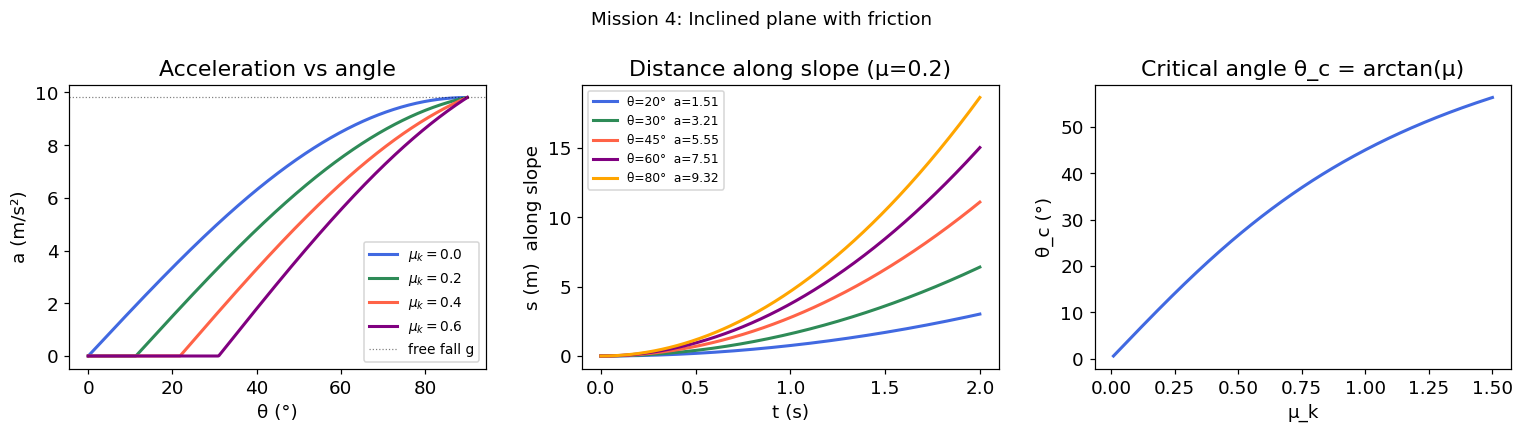

In [6]:
theta_s, mu_k_s = sp.symbols('theta mu_k', positive=True)

# ── strict FBD → EOM ──────────────────────────────────────────────────
N_incline = m * g_s * sp.cos(theta_s)
f_incline = mu_k_s * N_incline
a_incline = g_s * (sp.sin(theta_s) - mu_k_s * sp.cos(theta_s))

display(Math(rf'N = mg\cos\theta = {sp.latex(N_incline)}'))
display(Math(rf'f = \mu_k N = {sp.latex(f_incline)}'))
display(Math(rf'a = g(\sin\theta - \mu_k\cos\theta) = {sp.latex(a_incline)}'))

# critical angle where motion begins
theta_crit = sp.atan(mu_k_s)
display(Math(rf'\text{{Critical angle }}: \theta_c = \arctan(\mu_k) = {sp.latex(theta_crit)}'))

# ── NumPy: loop over angles and friction coefficients ─────────────────
theta_arr = np.linspace(0, np.pi/2, 500)
mu_vals4  = [0.0, 0.2, 0.4, 0.6]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors4 = ['royalblue','seagreen','tomato','purple']

for mu_v, col in zip(mu_vals4, colors4):       # loop over μ values
    a_arr4 = g_v * (np.sin(theta_arr) - mu_v*np.cos(theta_arr))
    a_arr4 = np.where(a_arr4 < 0, 0, a_arr4)   # static friction caps at 0
    axes[0].plot(np.degrees(theta_arr), a_arr4, color=col, lw=2, label=rf'$\mu_k={mu_v}$')

axes[0].axhline(g_v, color='k', lw=0.8, ls=':', alpha=0.5, label='free fall g')
axes[0].set_xlabel('θ (°)'); axes[0].set_ylabel('a (m/s²)')
axes[0].set_title('Acceleration vs angle'); axes[0].legend(fontsize=9)

# time trajectory for several angles, μ=0.2
mu_v4 = 0.2; t_v4 = np.linspace(0, 2, 300)
for theta_v, col in zip([20,30,45,60,80], ['royalblue','seagreen','tomato','purple','orange']):
    th = np.radians(theta_v)
    a_v4 = max(0, g_v*(np.sin(th) - mu_v4*np.cos(th)))
    axes[1].plot(t_v4, 0.5*a_v4*t_v4**2, color=col, lw=2, label=f'θ={theta_v}°  a={a_v4:.2f}')

axes[1].set_xlabel('t (s)'); axes[1].set_ylabel('s (m)  along slope')
axes[1].set_title(f'Distance along slope (μ={mu_v4})')
axes[1].legend(fontsize=8)

# critical angle vs μ
mu_arr4 = np.linspace(0.01, 1.5, 300)
theta_c = np.degrees(np.arctan(mu_arr4))
axes[2].plot(mu_arr4, theta_c, color='royalblue', lw=2)
axes[2].set_xlabel('μ_k'); axes[2].set_ylabel('θ_c (°)')
axes[2].set_title('Critical angle θ_c = arctan(μ)')

plt.suptitle('Mission 4: Inclined plane with friction', fontsize=12)
plt.tight_layout(); plt.show()

---
# Mission 5 — Double Pendulum (Coupled 2nd-order ODEs)

```
    ●  pivot
    │\  θ₁
    │ \
    │  ● m₁
    │   \\ θ₂
    │    \\
    │     ● m₂
```

**FBD via Lagrangian (most rigorous for coupled systems):**  
$T = \frac{1}{2}(m_1+m_2)l_1^2\dot{\theta}_1^2 + \frac{1}{2}m_2 l_2^2\dot{\theta}_2^2 + m_2 l_1 l_2\dot{\theta}_1\dot{\theta}_2\cos(\theta_1-\theta_2)$  
$V = -(m_1+m_2)gl_1\cos\theta_1 - m_2 g l_2\cos\theta_2$  
$\mathcal{L} = T - V$, then $\frac{d}{dt}\partial_{\dot{q}} - \partial_q = 0$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

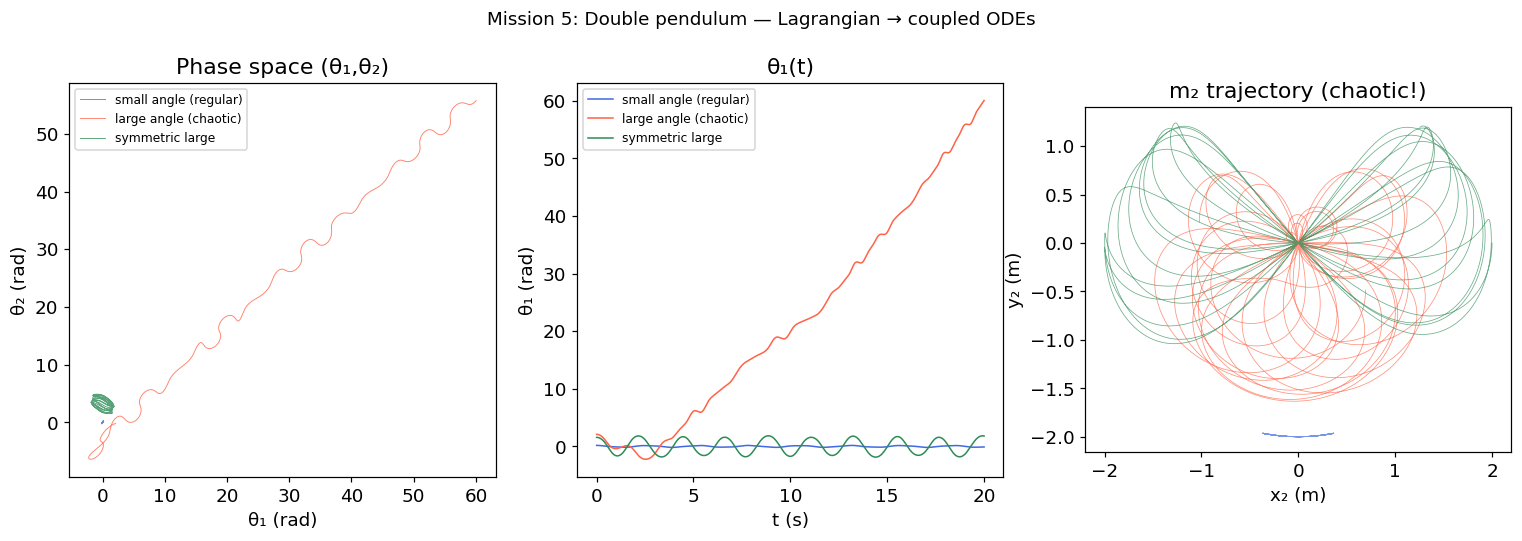

In [7]:
t_dp = sp.Symbol('t')
th1  = sp.Function('theta_1')(t_dp)
th2  = sp.Function('theta_2')(t_dp)
m1_d, m2_d, l1_d, l2_d, g_d = sp.symbols('m_1 m_2 l_1 l_2 g', positive=True)

# ── kinetic energy ─────────────────────────────────────────────────────
T_dp = (sp.Rational(1,2)*(m1_d+m2_d)*l1_d**2*th1.diff(t_dp)**2
      + sp.Rational(1,2)*m2_d*l2_d**2*th2.diff(t_dp)**2
      + m2_d*l1_d*l2_d*th1.diff(t_dp)*th2.diff(t_dp)*sp.cos(th1-th2))

# ── potential energy ───────────────────────────────────────────────────
V_dp = (-(m1_d+m2_d)*g_d*l1_d*sp.cos(th1)
       - m2_d*g_d*l2_d*sp.cos(th2))

L_dp = T_dp - V_dp
display(Math(rf'\mathcal{{L}} = T - V'))
display(Math(rf'T = {sp.latex(T_dp)}'))
display(Math(rf'V = {sp.latex(V_dp)}'))

# ── Euler-Lagrange equations ───────────────────────────────────────────
EL1 = sp.diff(sp.diff(L_dp, th1.diff(t_dp)), t_dp) - sp.diff(L_dp, th1)
EL2 = sp.diff(sp.diff(L_dp, th2.diff(t_dp)), t_dp) - sp.diff(L_dp, th2)
EL1_s = sp.simplify(EL1)
EL2_s = sp.simplify(EL2)
display(Math(rf'\text{{EL}}_1 = {sp.latex(EL1_s)} = 0'))
display(Math(rf'\text{{EL}}_2 = {sp.latex(EL2_s)} = 0'))

# ── NumPy: numerical integration (small angle linearisation for speed) ─
# Full nonlinear equations (standard form)
def double_pendulum(t, y, m1, m2, l1, l2, g):
    th1, w1, th2, w2 = y
    d = th1 - th2
    denom1 = (m1+m2)*l1 - m2*l1*np.cos(d)**2
    denom2 = l2/l1 * denom1

    dw1 = (m2*l1*w1**2*np.sin(d)*np.cos(d)
           + m2*g*np.sin(th2)*np.cos(d)
           + m2*l2*w2**2*np.sin(d)
           - (m1+m2)*g*np.sin(th1)) / denom1

    dw2 = (-m2*l2*w2**2*np.sin(d)*np.cos(d)
           + (m1+m2)*(g*np.sin(th1)*np.cos(d) - l1*w1**2*np.sin(d) - g*np.sin(th2))) / denom2

    return [w1, dw1, w2, dw2]

t_dp_arr = np.linspace(0, 20, 5000)

# loop over initial conditions
IC_sets = [
    ([np.radians(10),  0, np.radians(10),  0], 'royalblue', 'small angle (regular)'),
    ([np.radians(120), 0, np.radians(-10), 0], 'tomato',    'large angle (chaotic)'),
    ([np.radians(90),  0, np.radians(90),  0], 'seagreen',  'symmetric large'),
]

m1_v=1; m2_v=1; l1_v=1; l2_v=1

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for IC, col, label in IC_sets:               # loop over ICs
    sol5 = solve_ivp(double_pendulum, [0,20], IC,
                     t_eval=t_dp_arr, rtol=1e-8, atol=1e-10,
                     args=(m1_v,m2_v,l1_v,l2_v,g_v))
    th1_t, w1_t, th2_t, w2_t = sol5.y

    # Cartesian
    x1_t =  l1_v*np.sin(th1_t)
    y1_t = -l1_v*np.cos(th1_t)
    x2_t =  x1_t + l2_v*np.sin(th2_t)
    y2_t =  y1_t - l2_v*np.cos(th2_t)

    axes[0].plot(th1_t, th2_t, color=col, lw=0.6, alpha=0.8, label=label)
    axes[1].plot(t_dp_arr, th1_t, color=col, lw=1, label=label)
    axes[2].plot(x2_t, y2_t, color=col, lw=0.5, alpha=0.7)

axes[0].set_xlabel('θ₁ (rad)'); axes[0].set_ylabel('θ₂ (rad)')
axes[0].set_title('Phase space (θ₁,θ₂)'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('t (s)'); axes[1].set_ylabel('θ₁ (rad)')
axes[1].set_title('θ₁(t)'); axes[1].legend(fontsize=8)
axes[2].set_xlabel('x₂ (m)'); axes[2].set_ylabel('y₂ (m)')
axes[2].set_title('m₂ trajectory (chaotic!)')
axes[2].set_aspect('equal')

plt.suptitle('Mission 5: Double pendulum — Lagrangian → coupled ODEs', fontsize=12)
plt.tight_layout(); plt.show()

---
# Mission 6 — Rocket with Variable Mass and Drag

```
        ↑ thrust  T = v_e · dm/dt
        │
      ┌─┴─┐
      │ m │  ← mass decreasing
      └───┘
        ↓ W = m(t)g
        ↓ D = ½ρC_D A v²  (drag)
```

**Tsiolkovsky rocket equation (variable-mass FBD):**  
$m\dot{v} = T - mg - D = -\dot{m}v_e - mg - \frac{1}{2}\rho C_D A v^2$  
$\Delta v = v_e \ln(m_0/m_f)$ in vacuum

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Tsiolkovsky Δv (vacuum) vs exhaust velocity:
  ve=2000 m/s  →  Δv=3219 m/s  (3.22 km/s)
  ve=3000 m/s  →  Δv=4828 m/s  (4.83 km/s)
  ve=4000 m/s  →  Δv=6438 m/s  (6.44 km/s)
  ve=4500 m/s  →  Δv=7242 m/s  (7.24 km/s)


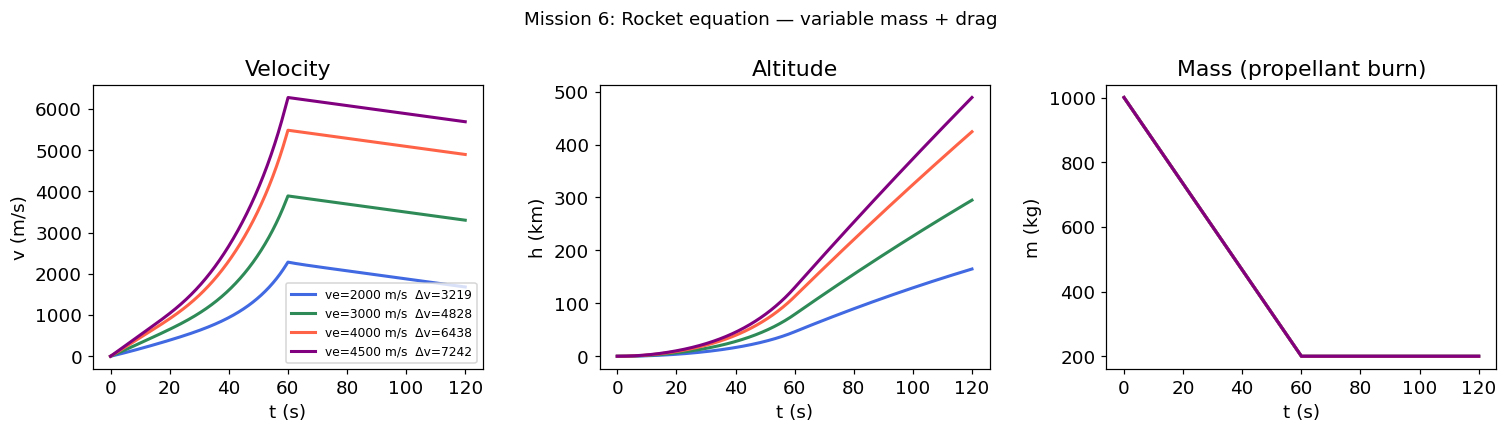

In [8]:
m_t_s, ve_s, mdot_s, rho_s, CD_s, A_s = sp.symbols(
    'm v_e dot_m rho C_D A', positive=True
)
v_r = sp.Symbol('v', real=True)

# ── Tsiolkovsky + drag ─────────────────────────────────────────────────
T_thrust = -mdot_s * ve_s
W_rocket = m_t_s * g_s
D_drag   = sp.Rational(1,2) * rho_s * CD_s * A_s * v_r**2

EOM_rocket = sp.Eq(m_t_s * v_r.diff(t_s) , T_thrust - W_rocket - D_drag)
display(Math(rf'\text{{FBD}} \Rightarrow {sp.latex(EOM_rocket)}'))

# Tsiolkovsky Δv (vacuum, constant thrust)
m0_s, mf_s = sp.symbols('m_0 m_f', positive=True)
Delta_v = ve_s * sp.ln(m0_s / mf_s)
display(Math(rf'\Delta v_{{\text{{vacuum}}}} = v_e \ln(m_0/m_f) = {sp.latex(Delta_v)}'))

# ── NumPy: integrate rocket trajectory ────────────────────────────────
# parameters
m0_v   = 1000.0   # kg total (wet)
mf_v   = 200.0    # kg dry mass
ve_v   = 3000.0   # m/s exhaust
burn_t = 60.0     # s burn time
mdot_v = -(mf_v - m0_v) / burn_t   # positive mass flow rate out (kg/s)
rho_v  = 1.2      # kg/m³ air
CD_v   = 0.3
A_v    = 0.2      # m²

def rocket_ode(t, y):
    v_rocket, h, m_now = y
    if m_now <= mf_v:
        T = 0.0
        dmdt = 0.0
    else:
        T = mdot_v * ve_v          # thrust
        dmdt = -mdot_v
    rho_h = rho_v * np.exp(-h/8500)   # atmospheric density scale height
    D = 0.5 * rho_h * CD_v * A_v * v_rocket**2 * np.sign(v_rocket)
    dvdt = (T - m_now*g_v - D) / m_now
    dhdt = v_rocket
    return [dvdt, dhdt, dmdt]

t_rkt = np.linspace(0, 120, 3000)

# loop over exhaust velocities
ve_list = [2000, 3000, 4000, 4500]
colors_r = ['royalblue','seagreen','tomato','purple']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ve_v2, col in zip(ve_list, colors_r):          # loop over ve
    T_v2 = mdot_v * ve_v2

    def rocket_ode_ve(t, y):
        v_r2, h2, m2 = y
        if m2 <= mf_v:
            Th2 = 0.0; dm2 = 0.0
        else:
            Th2 = mdot_v * ve_v2; dm2 = -mdot_v
        rho_h2 = rho_v * np.exp(-h2/8500)
        D2 = 0.5*rho_h2*CD_v*A_v*v_r2**2*np.sign(v_r2)
        return [(Th2 - m2*g_v - D2)/m2, v_r2, dm2]

    sol6 = solve_ivp(rocket_ode_ve, [0,120], [0,0,m0_v],
                     t_eval=t_rkt, rtol=1e-6)
    v6, h6, m6 = sol6.y
    dv_tsiol = ve_v2 * np.log(m0_v/mf_v)

    axes[0].plot(t_rkt, v6, color=col, lw=2, label=f've={ve_v2} m/s  Δv={dv_tsiol:.0f}')
    axes[1].plot(t_rkt, h6/1e3, color=col, lw=2)
    axes[2].plot(t_rkt, m6, color=col, lw=2)

axes[0].set_xlabel('t (s)'); axes[0].set_ylabel('v (m/s)')
axes[0].set_title('Velocity'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('t (s)'); axes[1].set_ylabel('h (km)')
axes[1].set_title('Altitude')
axes[2].set_xlabel('t (s)'); axes[2].set_ylabel('m (kg)')
axes[2].set_title('Mass (propellant burn)')

# Tsiolkovsky ideal Δv for reference
dv_ideal = np.array(ve_list) * np.log(m0_v/mf_v)
print('Tsiolkovsky Δv (vacuum) vs exhaust velocity:')
for ve_v2, dv in zip(ve_list, dv_ideal):
    print(f'  ve={ve_v2} m/s  →  Δv={dv:.0f} m/s  ({dv/1e3:.2f} km/s)')

plt.suptitle('Mission 6: Rocket equation — variable mass + drag', fontsize=12)
plt.tight_layout(); plt.show()

---
# Torch Batch: Spring-Mass-Damper over (k, c, F₀) Grid

Run 8,000 simultaneous step-response simulations, compute overshoot and settling time  
for the full spring-mass-damper design space.

Batch size: 8000


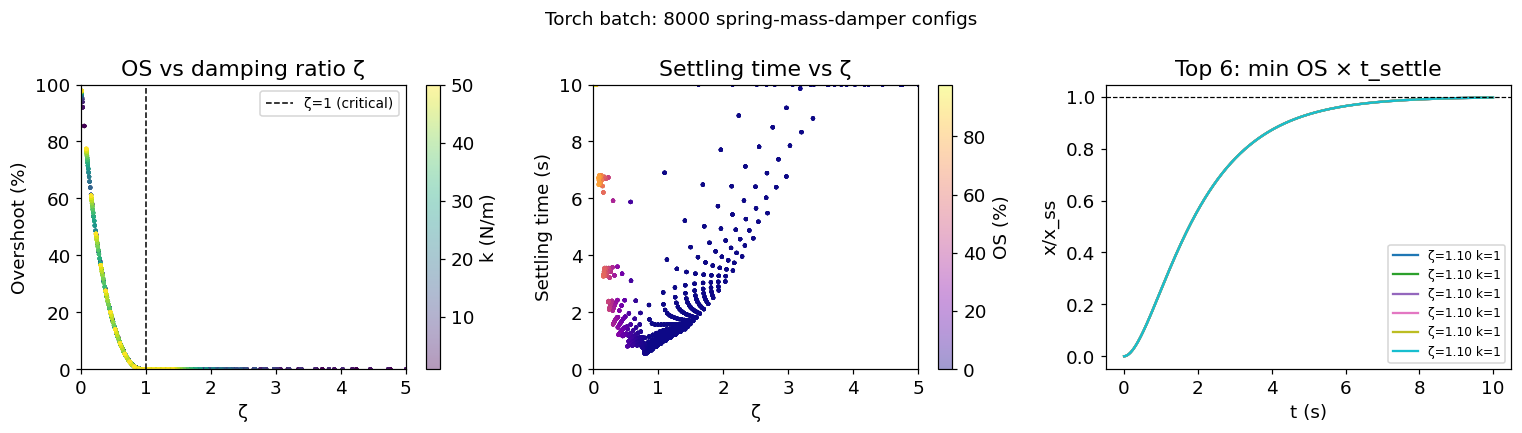

In [9]:
torch.manual_seed(0)

# parameter grid
k_grid  = torch.linspace(1.0, 50.0, 20, dtype=torch.float64)
c_grid  = torch.linspace(0.1, 20.0, 20, dtype=torch.float64)
F0_grid = torch.linspace(1.0, 10.0, 20, dtype=torch.float64)

Kg, Cg, Fg = torch.meshgrid(k_grid, c_grid, F0_grid, indexing='ij')
Kf = Kg.reshape(-1); Cf = Cg.reshape(-1); Ff = Fg.reshape(-1)
N_b = Kf.shape[0]
print(f'Batch size: {N_b}')

m_b  = torch.tensor(1.0, dtype=torch.float64)
dt_b = 0.005; N_st = 2000

# state: (N_b, 2) = [x, xdot]
state = torch.zeros(N_b, 2, dtype=torch.float64)
x_hist_b = torch.zeros(N_b, N_st, dtype=torch.float64)

for step in range(N_st):
    x_b, xd_b  = state[:, 0], state[:, 1]
    F_ext      = Ff                              # constant step force
    xdd_b      = (F_ext - Cf*xd_b - Kf*x_b) / m_b
    state[:, 1] = xd_b + xdd_b * dt_b
    state[:, 0] = x_b  + xd_b  * dt_b
    x_hist_b[:, step] = state[:, 0]

# metrics
x_ss    = Ff / Kf                                # steady-state x = F/k
OS_b    = ((x_hist_b.max(dim=1).values - x_ss) / x_ss * 100).clamp(min=0)
settled = (x_hist_b - x_ss.unsqueeze(1)).abs() > 0.02*x_ss.abs().unsqueeze(1)
t_set_b = (N_st - settled.float().flip(dims=[1]).argmax(dim=1).float()) * dt_b

# damping ratio per config
wn_b   = torch.sqrt(Kf / m_b)
zeta_b = Cf / (2 * m_b * wn_b)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sc0 = axes[0].scatter(zeta_b.numpy(), OS_b.numpy(), c=Kf.numpy(),
                       cmap='viridis', s=3, alpha=0.4)
plt.colorbar(sc0, ax=axes[0], label='k (N/m)')
axes[0].set_xlabel('ζ'); axes[0].set_ylabel('Overshoot (%)')
axes[0].set_title('OS vs damping ratio ζ')
axes[0].axvline(1.0, color='k', lw=1, ls='--', label='ζ=1 (critical)')
axes[0].set_xlim(0, 5); axes[0].set_ylim(0, 100); axes[0].legend(fontsize=9)

sc1 = axes[1].scatter(zeta_b.numpy(), t_set_b.numpy(), c=OS_b.numpy(),
                       cmap='plasma', s=3, alpha=0.4)
plt.colorbar(sc1, ax=axes[1], label='OS (%)')
axes[1].set_xlabel('ζ'); axes[1].set_ylabel('Settling time (s)')
axes[1].set_title('Settling time vs ζ')
axes[1].set_xlim(0, 5); axes[1].set_ylim(0, 10)

# best 6 configs: min OS × t_settle
score_b = OS_b * t_set_b
best6   = torch.topk(score_b, 6, largest=False).indices
t_axis_b = np.arange(N_st) * dt_b
cols6 = plt.cm.tab10(np.linspace(0,1,6))
for bi, col in zip(best6, cols6):
    axes[2].plot(t_axis_b, x_hist_b[bi].numpy() / x_ss[bi].item(),
                 color=col, lw=1.5,
                 label=rf'ζ={zeta_b[bi]:.2f} k={Kf[bi]:.0f}')
axes[2].axhline(1, color='k', lw=0.8, ls='--')
axes[2].set_xlabel('t (s)'); axes[2].set_ylabel('x/x_ss')
axes[2].set_title('Top 6: min OS × t_settle')
axes[2].legend(fontsize=8)

plt.suptitle('Torch batch: 8000 spring-mass-damper configs', fontsize=12)
plt.tight_layout(); plt.show()

---
# Summary — FBD → Diff → Time

| Mission | FBD forces | ODE order | Key result |
|---------|-----------|-----------|------------|
| 1 Block | W, N, f, F_A | 1st (linear) | a = (F_A − μmg)/m  constant |
| 2 Atwood | W₁, W₂, T | 1st (linear) | a = (m₁−m₂)g/(m₁+m₂) |
| 3 SMD | W, N, F_s, F_d, F_A | **2nd** | ζ determines under/over/critical damping |
| 4 Inclined | W∥, W⊥, N, f | 1st (linear) | a = g(sinθ − μcosθ), θ_c = arctan(μ) |
| 5 Double pendulum | gravity × 2, tension × 2 | **2nd coupled** | chaos above ~20° initial angle |
| 6 Rocket | T, W(t), D | 1st variable-mass | Δv = v_e ln(m₀/m_f) |
| Torch | — | discrete | 8000-config OS / t_settle Pareto |